<a href="https://colab.research.google.com/github/FelixOtero19/Introducion_Ciencia_de_datos/blob/main/02_clase_laboratorio_ESTUDIANTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Laboratorio · Clase 2
## Airbnb en Nueva York — explorar una tabla real

**S100 · Introducción a la Ciencia de Datos** · UTP · Prof. Gabriel Soto

---

### Cómo trabajamos

- Trabajan en **su sala** (breakout room). **Roten quién teclea** cada tarea: el que
  comparte pantalla cambia, no siempre el mismo.
- Si a alguien no le abre el cuaderno, igual aporta: lean el enunciado en voz alta y
  discutan la respuesta antes de que el que teclea escriba.
- Son **10 tareas cortas**. Casi todas son de **una línea**. Si una les toma más de
  4 minutos, salten a la siguiente y vuelvan al final.
- Cada tarea trae una **💡 pista** con la función exacta que necesitan. **Úsenla.**
- Todo lo que necesitan lo vimos hoy en el cuaderno de clase. Ténganlo abierto al lado.
- **No es sumativo.** Cuenta como participación.

### 🤖 Sobre el uso de IA

**Está permitido**, con una sola condición: **que puedan explicar lo que hicieron.**

Concretamente, si usan IA para una tarea, díganme una de estas dos cosas:

- **qué hace ese código**, línea por línea — no hace falta que sea perfecto, hace falta
  que sepan qué están entregando; **o**
- **qué alternativa pensaron** antes de preguntar, aunque no les haya funcionado.

No hay penalización por usarla. La hay por entregar código que no saben leer: en esta
maestría ustedes firman el análisis, y no se puede defender lo que no se entiende.

### Qué presenta cada sala al cerrar (5 min)

| | |
|---|---|
| 1 | **Un hallazgo** — una frase, con el número que la respalda |
| 2 | **El gráfico** que lo sostiene — ¿se entiende sin que ustedes hablen? |
| 3 | **Una advertencia** — algo que estos datos **NO** permiten concluir |
| 4 | **Dónde usaron IA** — y qué hace ese código, o qué alternativa pensaron |

> El punto 3 es el que más importa. Saber qué **no** se puede afirmar con los datos que
> hay es lo que separa esta maestría de un curso de programación.

---
## Paso 0 · Preparar el entorno

Ejecuta las dos celdas de abajo. **No hay que escribir nada aquí.**

In [42]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline

AZUL, GRIS, REJILLA = "#13294B", "#5F6472", "#D3D8E0"
plt.rcParams.update({"figure.figsize": (8, 4.2), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": REJILLA, "axes.titleweight": "bold", "font.size": 10})
print("Listo.")

Listo.


In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
from pathlib import Path
ARCHIVO = Path("datos") / "AB_NYC_2019.csv"

def _simular(n=3000):
    r = np.random.default_rng(2026)
    dist = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
    base = dict(zip(dist, [5.10, 4.70, 4.45, 4.30, 4.35]))
    tipo = ["Entire home/apt", "Private room", "Shared room"]
    aj = dict(zip(tipo, [0.55, -0.10, -0.75]))
    d  = r.choice(dist, n, p=[.44, .41, .12, .02, .01])
    rt = r.choice(tipo, n, p=[.52, .45, .03])
    precio = np.exp([base[x] for x in d] + np.array([aj[t] for t in rt])
                    + r.normal(0, .55, n)).round().astype(int)
    precio[r.random(n) < .0004] = 0
    precio[r.choice(n, n // 900, replace=False)] = r.integers(3000, 10001, n // 900)
    nunca = r.random(n) < .206
    nrev = np.where(nunca, 0, 1 + r.negative_binomial(1.1, .07, n))
    fechas = pd.to_datetime("2019-07-08") - pd.to_timedelta(r.integers(0, 1500, n), unit="D")
    return pd.DataFrame({
        "id": np.arange(n), "neighbourhood_group": d,
        "neighbourhood": [f"{x[:3]}-Barrio {r.integers(1, 9)}" for x in d],
        "latitude": (40.73 + r.normal(0, .05, n)).round(5),
        "longitude": (-73.95 + r.normal(0, .05, n)).round(5),
        "room_type": rt, "price": precio,
        "minimum_nights": r.choice([1, 2, 3, 5, 7, 30], n, p=[.4, .25, .15, .1, .06, .04]),
        "number_of_reviews": nrev,
        "last_review": pd.Series(fechas).where(~nunca),
        "reviews_per_month": np.where(nunca, np.nan, (r.gamma(1.8, .65, n) + .01).round(2)),
        "availability_365": r.integers(0, 366, n)})

if ARCHIVO.exists():
    df = pd.read_csv(ARCHIVO, parse_dates=["last_review"])
    FUENTE = "Kaggle · NYC Airbnb Open Data 2019 (datos reales)"
else:
    df = _simular()
    FUENTE = "⚠️ DATOS SIMULADOS — falta datos/AB_NYC_2019.csv. No citen estas cifras."

print(FUENTE)
print(df.shape[0], "alojamientos ×", df.shape[1], "columnas")

⚠️ DATOS SIMULADOS — falta datos/AB_NYC_2019.csv. No citen estas cifras.
3000 alojamientos × 12 columnas


### El caso

Una cadena hotelera panameña quiere entender el mercado de alojamiento de corta estancia
antes de entrar. Les pasan la tabla de **Airbnb en Nueva York** y tres preguntas.

| Columna | Qué es |
|---|---|
| `neighbourhood_group` | Distrito: Manhattan, Brooklyn, Queens, Bronx, Staten Island |
| `room_type` | Apartamento entero / habitación privada / habitación compartida |
| `price` | Precio por noche (USD) |
| `minimum_nights` | Noches mínimas |
| `number_of_reviews` | Total de reseñas |
| `reviews_per_month` | Reseñas por mes |
| `availability_365` | Días disponibles al año |

---
# Parte 1 · Calentamiento con NumPy
> Cuaderno de clase, sección 1

Dos tareas de un minuto para soltar la mano. **Sin `for`.**

### ✏️ Tarea 1 — Vectorización

La gerencia quiere ver estos cinco precios **con un aumento del 15 %**.

Hazlo en **una línea**, sin `for`.

> 💡 A un arreglo de NumPy se le puede multiplicar por un número y se aplica a todos:
> `arreglo * 1.15`

In [45]:
precios = np.array([120, 85, 300, 45, 210])

# TODO:
f"Los nuevos precios son {(precios*1.15).round(2)}."

'Los nuevos precios son [138.    97.75 345.    51.75 241.5 ].'

### ✏️ Tarea 2 — Resumir un arreglo

Con el mismo arreglo `precios`: **¿cuál es el promedio, el más caro y el más barato?**
Y muestra además **los tres primeros** precios.

> 💡 Los resúmenes son métodos, van después del punto: `.mean()`, `.max()`, `.min()`.
> Para los tres primeros, rebanado: `precios[0:3]` — el "hasta" **no** se incluye.

In [46]:
# TODO:
f"El promedio es ${precios.mean()}, el más caro ${precios.max()}, el más barato ${precios.min()}."

'El promedio es $152.0, el más caro $300, el más barato $45.'

---
# Parte 2 · Conocer los datos antes de calcular nada
> Cuaderno de clase, sección 2.2

**Nunca** calculen nada antes de estas tres.

### ✏️ Tarea 3 — Mirar la tabla

Muestra las **primeras filas** de `df` para ver qué tiene.

> 💡 `df.head()`

In [47]:
# TODO:
df.head()

,id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,availability_365
0,0,Manhattan,Man-Barrio 2,40.69405,-73.91558,Entire home/apt,494,2,14,2015-07-13,4.09,24
1,1,Brooklyn,Bro-Barrio 8,40.76029,-73.89846,Entire home/apt,254,1,8,2017-09-01,5.39,209
2,2,Brooklyn,Bro-Barrio 5,40.68495,-73.97661,Entire home/apt,376,2,31,2017-07-16,2.38,240
3,3,Manhattan,Man-Barrio 4,40.74525,-73.98762,Entire home/apt,168,1,7,2016-07-25,0.75,80
4,4,Manhattan,Man-Barrio 6,40.81575,-74.01407,Private room,39,5,23,2018-08-27,1.99,348


### ✏️ Tarea 4 — El resumen numérico

Saca el resumen estadístico de las columnas numéricas.

Después **miren la fila `min` de `price`, y la fila `max`.** ¿Les cuadra?

> 💡 `df.describe()`

In [48]:
# TODO:
df.describe()

,id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,availability_365
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2369,2369.000000,3000.000000
mean,1499.500000,40.729515,-73.950665,205.068000,3.387667,12.285667,2017-06-13 09:23:28.695652096,1.216315,184.031000
min,0.000000,40.568140,-74.126750,0.000000,1.000000,0.000000,2015-05-31 00:00:00,0.020000,0.000000
25%,749.750000,40.696760,-73.983962,94.000000,1.000000,1.000000,2016-06-11 00:00:00,0.550000,89.000000
50%,1499.500000,40.729140,-73.951115,155.000000,2.000000,7.000000,2017-06-18 00:00:00,1.020000,184.000000
75%,2249.250000,40.761722,-73.916468,254.250000,3.000000,18.000000,2018-06-22 00:00:00,1.690000,276.000000
max,2999.000000,40.896630,-73.799530,7980.000000,30.000000,104.000000,2019-07-07 00:00:00,7.500000,365.000000
std,866.169729,0.049075,0.050356,283.981081,5.606174,14.595675,NaN,0.907819,106.047056


### ✏️ Tarea 5 — ¿Cuántos hay de cada distrito?

Cuenta cuántos alojamientos hay en cada `neighbourhood_group`.

> 💡 `df["columna"].value_counts()`

In [49]:
# TODO:
df["neighbourhood_group"].value_counts()



,count
neighbourhood_group,
Manhattan,1328
Brooklyn,1222
Queens,360
Bronx,55
Staten Island,35


---
# Parte 3 · ¿Dónde está el dinero?
> Cuaderno de clase, secciones 2.3 y 2.5

> **Pregunta de la gerencia #1:** *«¿Qué distrito es más caro, y por cuánto?»*

### ✏️ Tarea 6 — Filtrar con dos condiciones

**¿Cuántas habitaciones privadas hay en Brooklyn por menos de \$80 la noche?**

> 💡 Dos condiciones unidas con `&`, y **cada una entre paréntesis**:
> `df[(df["col1"] == "valor") & (df["col2"] < 80)]`
> Después cuenten las filas del resultado con `len(...)`.
>
> ⚠️ Si usan `and` en vez de `&`, sale un `ValueError`. Es normal: lo vimos en clase.

In [50]:
# TODO:
len(df[(df["neighbourhood_group"] == "Brooklyn") & (df["room_type"] == "Private room") & (df["price"] < 80)])

200

### ✏️ Tarea 7 — Precio por distrito

Calcula el **precio mediano** por distrito y ordénalo de mayor a menor.

Usamos la **mediana** y no la media. Después de lo que vieron en la Tarea 4,
¿por qué creen que es?

> 💡 `df.groupby("columna")["price"].median().sort_values(ascending=False)`

In [51]:
# TODO:
p = df.groupby("neighbourhood_group")["price"].median().sort_values(ascending=False)
p



,price
neighbourhood_group,
Manhattan,200.5
Brooklyn,135.0
Queens,104.0
Staten Island,91.0
Bronx,86.0


---
# Parte 4 · Un gráfico que se entienda solo
> Cuaderno de clase, sección 3

> **Pregunta de la gerencia #2:** *«Muéstrenmelo en una imagen que pueda poner en el
> informe sin explicarla.»*

### ✏️ Tarea 8 — El gráfico del hallazgo

Un **gráfico de barras horizontales** con el precio mediano por distrito (el de la Tarea 7).

Requisitos, y se revisan: **ordenado por valor**, con **título**, y con **etiqueta de eje
que incluya la unidad** (USD).

> 💡 Ya tienen el cálculo. Solo faltan las capas:
> `fig, ax = plt.subplots()` · `ax.barh(p.index, p.values, color=AZUL)` ·
> `ax.set_xlabel(...)` · `ax.set_title(...)` · `plt.show()`

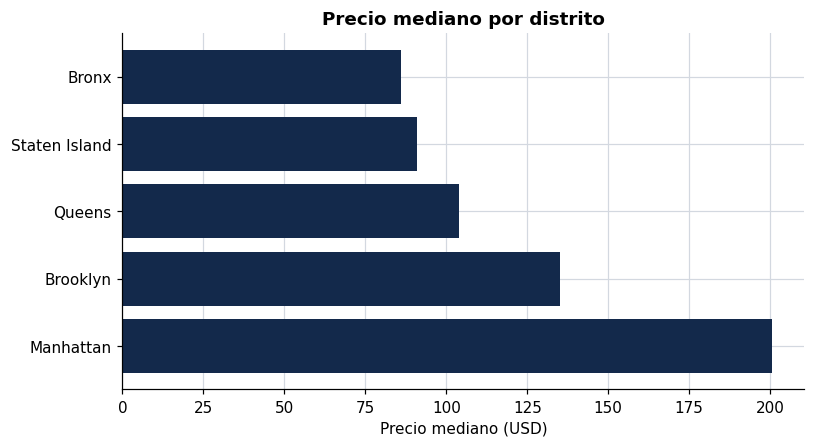

In [52]:
# TODO:
fig, ax = plt.subplots()
ax.barh(p.index, p.values, color=AZUL)
ax.set_xlabel("Precio mediano (USD)")
ax.set_title("Precio mediano por distrito")
plt.show()

### ✏️ Tarea 9 — ¿Cómo se reparten los precios?

Un **histograma** de `price`.

Háganlo **primero sin filtro** y miren lo que sale. Después repítanlo **solo con los
alojamientos que cuestan menos de \$500**.

> 💡 Sin filtro: `ax.hist(df["price"], bins=50, color=AZUL)`
> Con filtro: `sub = df[df["price"] < 500]` y luego `ax.hist(sub["price"], ...)`

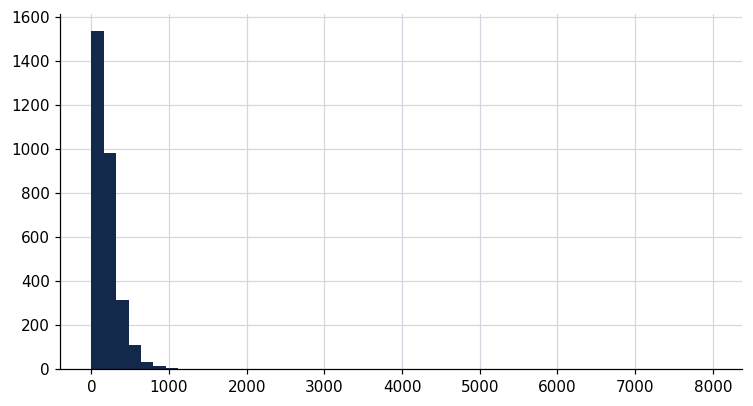

In [53]:
# TODO:
fig, ax = plt.subplots()
ax.hist(df["price"], bins=50, color=AZUL)
plt.show()

---
# Parte 5 · Lo que falta
> Cuaderno de clase, sección 2.6

> **Pregunta de la gerencia #3:** *«¿Los datos están completos?»*

### ✏️ Tarea 10 — Contar los faltantes, y preguntar por qué

Dos partes:

1. Cuenten cuántos valores faltan en cada columna.
2. La pregunta que importa: los alojamientos a los que les falta `reviews_per_month`,
   **¿cuántas reseñas totales tienen en promedio?**

> 💡 `df.isna().sum()`
> y después `df[df["reviews_per_month"].isna()]["number_of_reviews"].mean()`

In [54]:
# TODO:
df.isna().sum()

,0
id,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
last_review,631


---
# Parte 6 · Cierre de la sala

Ya tienen los números. **Ahora viene la parte que se presenta.**

Escriban las respuestas en la celda de texto de abajo (doble clic para editarla).
No hace falta que sea bonito; hace falta que sea **defendible**.

## 📋 Sala número: ______

**1 · Nuestro hallazgo** *(una frase, con el número que la respalda)*

>

**2 · El gráfico que lo sostiene** *(¿cuál de los dos? ¿se entiende solo?)*

>

**3 · Una advertencia — algo que estos datos NO permiten concluir**

>

*Ideas por si se atoran: ¿el precio publicado es el precio que se pagó? ¿un alojamiento sin
reseñas se alquiló alguna vez? ¿sabemos cuántos metros cuadrados tiene? ¿sirve Nueva York
2019 para decidir algo sobre Panamá 2026?*

**4 · Dónde usamos IA** *(en qué tarea, y qué hace ese código — o qué alternativa
pensamos antes de preguntar)*

>

1. #### Hallazgo
El distrito de Queens concentra 360 alojamientos, lo que lo ubica en tercer lugar después de Manhattan y Brooklyn



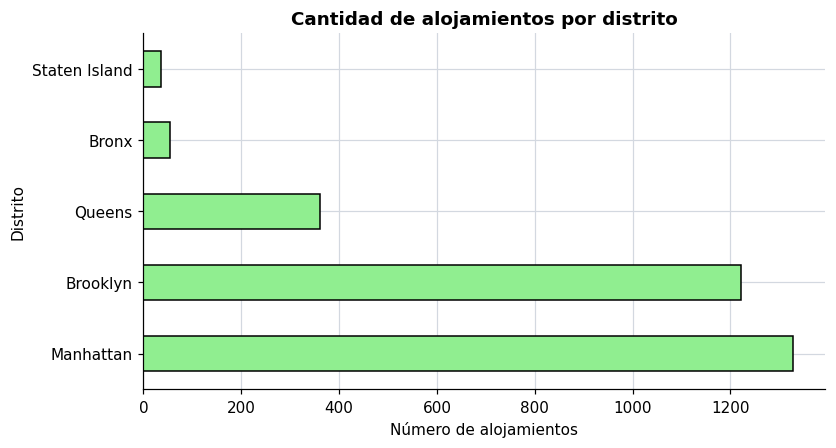

In [55]:
conteo = df["neighbourhood_group"].value_counts()

conteo.plot(kind="barh", color="lightgreen", edgecolor="black")
plt.title("Cantidad de alojamientos por distrito")
plt.xlabel("Número de alojamientos")
plt.ylabel("Distrito")
plt.show()


3. ###  Advertencia
Aunque Queens aparece con menos alojamientos que Manhattan y Brooklyn, estos datos no permiten concluir que la oferta sea insuficiente o que la demanda sea menor. Solo muestran la cantidad registrada en el dataset.

4. ## Donde se uso la IA
a IA sugirió el uso de value_counts() y un gráfico de barras horizontales. La alternativa manual sería agrupar con groupby("neighbourhood_group").size() y graficar con plt.barh()

---
### 🏁 Terminaron antes de tiempo

Tres opcionales, de menos a más difícil. Ninguna es obligatoria.

1. **Tabla cruzada.** Precio mediano por distrito (filas) **y** tipo de habitación (columnas).
   *Pista:* `df.pivot_table(index=..., columns=..., values="price", aggfunc="median")`
   ¿Una habitación compartida en Manhattan cuesta más que un apartamento entero en el Bronx?
2. **El mapa gratis.** Un `plt.scatter` con `longitude` en x y `latitude` en y.
   Sale Nueva York sin ninguna librería de mapas. *Usen `alpha=.1` o será una mancha negra.*
3. **Disponibilidad y precio.** ¿Los alojamientos disponibles casi todo el año
   (`availability_365 >= 350`) son más caros que los demás?
   Cuidado: los dos grupos tienen tamaños muy distintos, así que reporten también la **n**.

In [56]:
# Tabla cruzda
tabla = df.pivot_table(
    index="neighbourhood_group",
    columns="room_type",
    values="price",
    aggfunc="median"
)

print(tabla)


room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                          116.0          69.5         21.0
Brooklyn                       192.0         100.0         59.5
Manhattan                      289.0         150.0         72.0
Queens                         150.0          85.0         44.0
Staten Island                  134.0          51.0          NaN


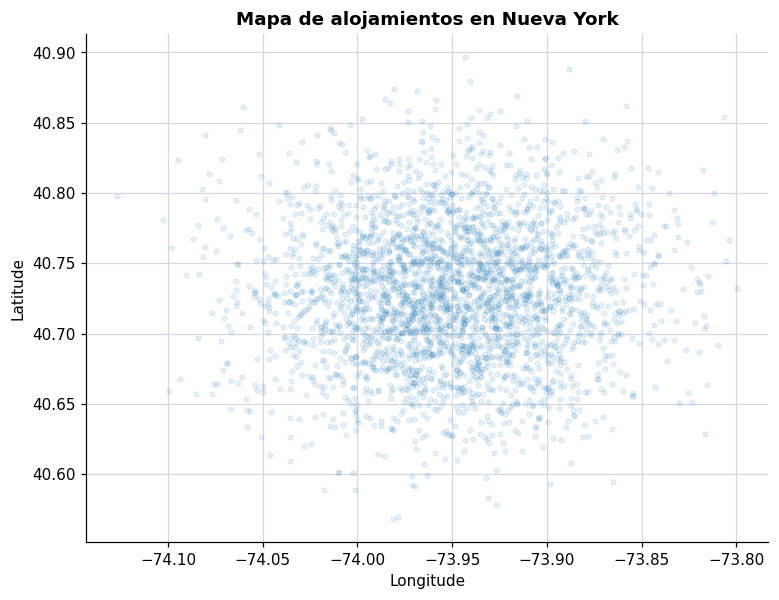

In [57]:
# Mapa Gratis

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["longitude"], df["latitude"], alpha=0.1, s=10)
plt.title("Mapa de alojamientos en Nueva York")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [62]:
# Disponibilidad y precio.
# Selecciona los precios de los alojamientos mas altos con disponibilidad casi todo el año (>= 350 días)
grupo_alto = df[df["availability_365"] >= 350]["price"]
# Selecciona los precios de los alojamientos con menos de 350 días de disponibilidad
grupo_bajo = df[df["availability_365"] < 350]["price"]
# Calcula y muestra la mediana de precios y el tamaño del grupo de alta disponibilidad
print(f"Mediana grupo alto: ${grupo_alto.median()} | n = {len(grupo_alto)}")
# Calcula y muestra la mediana de precios y el tamaño del grupo de baja disponibilidad
print(f"Mediana grupo bajo: ${grupo_bajo.median()} | n = {len(grupo_bajo)}")



Mediana grupo alto: $147.5 | n = 142
Mediana grupo bajo: $156.0 | n = 2858
